1. Solar Battery Arbitrage/Configuration & Setup:

Imports core libraries (math, pandas, entsoe) and initialises the ENTSO-E client for European energy market data.
Defines countries (AT, BE, BG, CZ, FR, GR, HU, ES) with their full names for reporting.
Models a Tesla Powerwall 3 or similar with 13.5 kWh capacity, 4.6 kW discharge, and 5.0 kW charge rate.
Sets cost assumptions at €7,200 per Powerwall and €1,000 per gateway (ex-VAT, ex-installation).
Arbitrage logic targets covering 20% of average peak-hour energy, using the top-5 price hours per day.
Data range is set to the full calendar year 2024 (UTC), from 1 Jan 2024 to 1 Jan 2025.

In [28]:
import math
import pandas as pd
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError
from requests import HTTPError
utility_cost_per_kWh_eur = 300.0
client = EntsoePandasClient(api_key="7308a46a-2e78-4bf2-a552-3295649e49e3")  

preselected_countries = ["AT", "BE", "BG", "CZ", "FR", "GR", "HU", "ES"]

country_names = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CZ": "Czech Republic",
    "FR": "France",
    "GR": "Greece",
    "HU": "Hungary",
    "ES": "Spain",
    "SI": "Slovenia",
}

# Powerwall 3 specs
pw_energy_MWh   = 13.5 / 1000.0  # 13.5 kWh
pw_discharge_MW = 4.6  / 1000.0  # 4.6 kW
pw_charge_MW    = 5.0  / 1000.0  # 5.0 kW

# Cost assumptions (excluding VAT, installation)
price_powerwall_eur = 7200.0
price_gateway_eur   = 1000.0  # one gateway per country/system

# Design choices
target_fraction = 0.50        # cover 50% of average peak-hour energy
STRONG_SOLAR_THRESHOLD = 0.20 # strong solar hours = >20% of peak solar
N_PEAK = 5                    # top-5 price hours per day

start_2024 = pd.Timestamp("2024-01-01", tz="UTC")
end_2024   = pd.Timestamp("2025-01-01", tz="UTC")

2. Fetch ENTSO-E Data

Queries the ENTSO-E Transparency Platform once per country for the full target year,
retrieving day-ahead prices (resampled to hourly) and the actual generation mix.
Generation columns with a MultiIndex are flattened to keep only the "Actual Aggregated"
series per technology. Results are cached in the raw_data dictionary so that
downstream cells (peak-hour volume, price spread, ROI) read from memory instead of
re-querying the API. HTTP errors and empty responses are logged and skipped.

In [ ]:
# Block 2: fetch ENTSO-E data once per country and cache.
# Both block 3 and block 4 read from raw_data instead of re-querying.

raw_data = {}  # cc -> {"prices_hourly": Series, "gen_agg": DataFrame}
failed_fetch = []

for cc in preselected_countries:
    print(f"=== {cc} ===")
    try:
        # Day-ahead prices, hourly
        prices = client.query_day_ahead_prices(cc, start=start_2024, end=end_2024)
        if prices.empty:
            print("  No price data")
            failed_fetch.append(cc)
            continue
        prices_hourly = prices.resample("1h").mean()

        # Generation mix
        gen = client.query_generation(cc, start=start_2024, end=end_2024)
        if gen.empty:
            print("  No generation data")
            failed_fetch.append(cc)
            continue

        # Flatten MultiIndex columns to just the technology name
        if isinstance(gen.columns, pd.MultiIndex):
            mask = gen.columns.get_level_values(1) == "Actual Aggregated"
            gen_agg = gen.loc[:, mask].copy()
            gen_agg.columns = gen_agg.columns.get_level_values(0)
        else:
            gen_agg = gen.copy()

        raw_data[cc] = {
            "prices_hourly": prices_hourly,
            "gen_agg": gen_agg,
        }
        print(f"  [OK] prices: {len(prices_hourly)} h, gen: {gen_agg.shape}")

    except Exception as e:
        print(f"  [ERROR] {e}")
        failed_fetch.append(cc)

print("\nFetched:", list(raw_data.keys()))
print("Failed:", failed_fetch)


=== AT ===
  [OK] prices: 8785 h, gen: (35136, 13)
=== BE ===
  [OK] prices: 8785 h, gen: (8784, 12)
=== BG ===
  [OK] prices: 8785 h, gen: (8784, 11)
=== CZ ===
  [OK] prices: 8785 h, gen: (22104, 15)
=== FR ===
  [OK] prices: 8785 h, gen: (9720, 12)
=== GR ===
  [OK] prices: 8785 h, gen: (8782, 7)
=== HU ===
  [OK] prices: 8785 h, gen: (35136, 14)
=== ES ===
  [OK] prices: 8785 h, gen: (35133, 20)

Fetched: ['AT', 'BE', 'BG', 'CZ', 'FR', 'GR', 'HU', 'ES']
Failed: []


3. Mean MWh in top‑5 price hours per day (mean_peak_MWh): 

For each country, fetches day-ahead prices (resampled to hourly) and actual generation
from ENTSO-E.
Both series are inner-joined on a shared hourly index; rows with NaNs are dropped.
Days with fewer than 5 valid hours are skipped; the top-5 highest-price hours are selected from the rest.
The mean generation volume across all such peak hours in 2024 is stored in mean_peak_MWh.
Countries with missing data, API errors, or no qualifying days are logged in failed_mean.

In [18]:
# Block 3: mean grid generation in top-5 price hours, AND mean solar
# available in strong-solar hours (for feasibility check in block 5).
#
# Strong-solar hours are identified from the sunny half of the year (April-October
# inclusive) so winter midday hours don't get classified as "strong" just because
# the yearly hour-of-day average crosses the threshold.
#
# Reads from raw_data (no API calls). Top-5 peak hours are found with vectorized
# groupby().rank() instead of a per-day Python loop.

SUMMER_MONTHS = list(range(4, 11))  # April through October inclusive

mean_peak_MWh = {}  # cc -> mean total grid MWh per peak hour (demand side)
mean_solar_charge_MWh = {}  # cc -> mean solar MWh per strong-solar hour (Apr-Oct)
strong_hours_by_cc = {}  # cc -> list of hour-of-day flagged strong
failed_mean = []

for cc in preselected_countries:
    print(f"\n=== {cc} ===")
    if cc not in raw_data:
        failed_mean.append(cc)
        continue

    prices_hourly = raw_data[cc]["prices_hourly"]
    gen_agg = raw_data[cc]["gen_agg"]

    # Total grid generation, hourly MWh
    total_gen_MW_15min = gen_agg.sum(axis=1)
    total_gen_MWh_hourly = total_gen_MW_15min.resample("1h").sum() * 0.25

    df = pd.DataFrame(index=prices_hourly.index)
    df["price_EUR_MWh"] = prices_hourly
    df = df.join(total_gen_MWh_hourly.to_frame(name="volume_MWh"), how="inner").dropna()
    if df.empty:
        print("  No overlap between prices and generation")
        failed_mean.append(cc)
        continue

    df["date"] = df.index.date
    df["hour"] = df.index.hour
    df["month"] = df.index.month

    # Vectorized top-5 peak hours per day (full year)
    day_counts = df.groupby("date")["price_EUR_MWh"].transform("count")
    df["rank"] = df.groupby("date")["price_EUR_MWh"].rank(
        method="first", ascending=False
    )
    df["is_peak"] = (df["rank"] <= N_PEAK) & (day_counts >= N_PEAK)

    peak_df = df[df["is_peak"]]
    if peak_df.empty:
        print("  No peak hours found")
        failed_mean.append(cc)
        continue
    mean_peak = peak_df["volume_MWh"].mean()
    mean_peak_MWh[cc] = mean_peak

    # Strong-solar hours: identify hour-of-day profile from April-October only
    if "Solar" in gen_agg.columns:
        solar_MWh_hourly = gen_agg["Solar"].resample("1h").sum() * 0.25
        sdf = df.join(solar_MWh_hourly.to_frame(name="solar_MWh"), how="inner").dropna()
        sdf_summer = sdf[sdf["month"].isin(SUMMER_MONTHS)]
        if not sdf_summer.empty:
            hourly_profile = sdf_summer.groupby("hour")["solar_MWh"].mean()
            max_avg = hourly_profile.max()
            if max_avg > 0:
                thr = STRONG_SOLAR_THRESHOLD * max_avg
                strong_hours = hourly_profile[hourly_profile > thr].index.tolist()
                if strong_hours:
                    strong_hours_by_cc[cc] = strong_hours
                    mean_solar_charge_MWh[cc] = sdf_summer.loc[
                        sdf_summer["hour"].isin(strong_hours), "solar_MWh"
                    ].mean()

    print(f"  Mean grid MWh in top-5 price hours: {mean_peak:,.0f} MWh/h")
    if cc in mean_solar_charge_MWh:
        print(
            f"  Mean solar MWh in strong-solar hours (Apr-Oct): "
            f"{mean_solar_charge_MWh[cc]:,.0f} MWh/h  (hours: {strong_hours_by_cc[cc]})"
        )
    else:
        print("  No strong-solar data")

print("\nPeak-hour volumes for:", list(mean_peak_MWh.keys()))
print("Failed:", failed_mean)



=== AT ===
  Mean grid MWh in top-5 price hours: 8,498 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 1,929 MWh/h  (hours: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

=== BE ===
  Mean grid MWh in top-5 price hours: 2,007 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 704 MWh/h  (hours: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

=== BG ===
  Mean grid MWh in top-5 price hours: 1,058 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 377 MWh/h  (hours: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

=== CZ ===
  Mean grid MWh in top-5 price hours: 5,263 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 904 MWh/h  (hours: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17])

=== FR ===
  Mean grid MWh in top-5 price hours: 17,315 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 1,756 MWh/h  (hours: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

=== GR ===
  Mean grid MWh in top-5 price hours: 1,554 MWh/h
  Mean solar MWh in strong-solar hours (Apr-Oct): 836 MWh/h  (

4. Price Spread: Strong Solar Hours vs. Peak Price Hours (2024)

For each country, fetches day-ahead prices (resampled to hourly) and solar generation
(extracted from the aggregated generation mix, also resampled to hourly), then inner-joins and drops NaNs.
Strong solar hours are identified by hour-of-day whose mean solar output exceeds 20% of the daily maximum.
Separately, the top-5 highest-price hours per day are flagged (days with fewer than 5 observations are skipped).
The mean price is computed for each group, and their difference — the arbitrage price spread — is stored in price_stats.
Countries with missing solar data, no qualifying solar or peak hours, or API errors are logged in failed_price.

In [25]:
# Block 4: price spreads for two daily arbitrage cycles.
#
# Cycle 1 (existing): discharge top-5 price hours, charge during strong-solar hours.
# Cycle 2 (new): discharge the next-best 3 price hours of each day (outside cycle 1),
#                charge during the cheapest 3 hours of each day (outside cycle 1).
#
# Reads from raw_data and reuses strong_hours_by_cc from cell 3.
# Cycle 2 hours are identified dynamically per day from the actual price shape.

N_PEAK_C2 = 3  # discharge hours per day for cycle 2
N_TROUGH_C2 = 3  # charge hours per day for cycle 2

price_stats = {}  # cc -> {mean_strong_price, mean_peak_price, price_spread,
#         mean_c2_peak_price, mean_c2_trough_price, c2_spread}
failed_price = []

for cc in preselected_countries:
    print(f"\n=== {cc} ===")
    if cc not in raw_data or cc not in strong_hours_by_cc:
        failed_price.append(cc)
        continue

    prices_hourly = raw_data[cc]["prices_hourly"]
    strong_hours = strong_hours_by_cc[cc]

    df = prices_hourly.to_frame(name="price_EUR_MWh").dropna()
    if df.empty:
        print("  No price data")
        failed_price.append(cc)
        continue

    df["hour"] = df.index.hour
    df["date"] = df.index.date
    df["is_strong"] = df["hour"].isin(strong_hours)

    # --- Cycle 1: top-5 peak vs. strong-solar (full year) ---
    day_counts = df.groupby("date")["price_EUR_MWh"].transform("count")
    df["rank_high"] = df.groupby("date")["price_EUR_MWh"].rank(
        method="first", ascending=False
    )
    df["rank_low"] = df.groupby("date")["price_EUR_MWh"].rank(
        method="first", ascending=True
    )
    df["is_peak"] = (df["rank_high"] <= N_PEAK) & (day_counts >= N_PEAK)

    strong_prices = df.loc[df["is_strong"], "price_EUR_MWh"]
    peak_prices = df.loc[df["is_peak"], "price_EUR_MWh"]
    if strong_prices.empty or peak_prices.empty:
        print("  Insufficient strong or peak prices for cycle 1")
        failed_price.append(cc)
        continue

    mean_strong = strong_prices.mean()
    mean_peak = peak_prices.mean()
    spread = mean_peak - mean_strong

    # --- Cycle 2: next-best 3 highs (after cycle 1) vs. cheapest 3 lows (after cycle 1) ---
    # Discharge: rank_high in (N_PEAK, N_PEAK + N_PEAK_C2]
    df["is_c2_peak"] = (
        (df["rank_high"] > N_PEAK)
        & (df["rank_high"] <= N_PEAK + N_PEAK_C2)
        & (day_counts >= N_PEAK + N_PEAK_C2)
    )
    # Charge: cheapest 3 hours that are NOT strong-solar hours
    df["rank_low_offstrong"] = (
        df.loc[~df["is_strong"]]
        .groupby("date")["price_EUR_MWh"]
        .rank(method="first", ascending=True)
    )
    df["is_c2_trough"] = df["rank_low_offstrong"] <= N_TROUGH_C2

    c2_peak_prices = df.loc[df["is_c2_peak"], "price_EUR_MWh"]
    c2_trough_prices = df.loc[df["is_c2_trough"], "price_EUR_MWh"]
    if c2_peak_prices.empty or c2_trough_prices.empty:
        print("  Insufficient prices for cycle 2; setting c2 spread to 0")
        mean_c2_peak = mean_c2_trough = c2_spread = 0.0
    else:
        mean_c2_peak = c2_peak_prices.mean()
        mean_c2_trough = c2_trough_prices.mean()
        c2_spread = mean_c2_peak - mean_c2_trough

    price_stats[cc] = {
        "mean_strong_price": mean_strong,
        "mean_peak_price": mean_peak,
        "price_spread": spread,
        "mean_c2_peak_price": mean_c2_peak,
        "mean_c2_trough_price": mean_c2_trough,
        "c2_spread": c2_spread,
    }
    print(
        f"  Cycle 1: strong {mean_strong:6.2f}  peak {mean_peak:6.2f}  spread {spread:6.2f} EUR/MWh"
    )
    print(
        f"  Cycle 2: trough {mean_c2_trough:6.2f}  peak {mean_c2_peak:6.2f}  spread {c2_spread:6.2f} EUR/MWh"
    )

print("\nPrice stats available for:", list(price_stats.keys()))
print("Failed:", failed_price)



=== AT ===
  Cycle 1: strong  76.64  peak 119.68  spread  43.04 EUR/MWh
  Cycle 2: trough  64.20  peak  97.68  spread  33.48 EUR/MWh

=== BE ===
  Cycle 1: strong  64.24  peak 106.67  spread  42.43 EUR/MWh
  Cycle 2: trough  53.51  peak  85.86  spread  32.35 EUR/MWh

=== BG ===
  Cycle 1: strong  90.50  peak 179.11  spread  88.61 EUR/MWh
  Cycle 2: trough  72.65  peak 117.57  spread  44.92 EUR/MWh

=== CZ ===
  Cycle 1: strong  74.96  peak 129.71  spread  54.75 EUR/MWh
  Cycle 2: trough  65.46  peak 102.06  spread  36.60 EUR/MWh

=== FR ===
  Cycle 1: strong  53.45  peak  89.60  spread  36.16 EUR/MWh
  Cycle 2: trough  39.75  peak  71.38  spread  31.64 EUR/MWh

=== GR ===
  Cycle 1: strong  85.85  peak 165.28  spread  79.42 EUR/MWh
  Cycle 2: trough  80.01  peak 113.40  spread  33.39 EUR/MWh

=== HU ===
  Cycle 1: strong  87.95  peak 177.35  spread  89.40 EUR/MWh
  Cycle 2: trough  70.81  peak 116.91  spread  46.10 EUR/MWh

=== ES ===
  Cycle 1: strong  53.84  peak  92.62  spread  38.

5. 10‑year ROI (fleet and per unit), with Powerwall constraints: 

For each country with valid data, the fleet is sized to cover 20% of the mean peak-hour grid energy, using whichever is the binding constraint — Powerwall energy capacity (13.5 kWh) or discharge power (4.6 kW).
Deliverable energy is derated by an average 85% utilisation (linearly degrading from 100% to 70% over 10 years).
Annual arbitrage margin is calculated as price_spread × effective_energy_MWh × 365, summed over 10 years.
Total investment covers all Powerwall units plus one gateway (€1,000), and both fleet-level and per-unit ROI are computed.
Results — including sizing, costs, margins, and ROI — are collected into rows_roi for final tabulation.

In [31]:
# Block 5: 10-year arbitrage ROI with two daily cycles, utility-scale storage.
#
# Storage is sized as continuous MWh capacity + MW power, priced at
# utility_cost_per_kWh_eur (€300/kWh installed, 2024 mid-range).
#
# Cycle 1: target_fraction extra MWh added to each of N_PEAK evening peak hours,
#          charged during strong-solar hours.
# Cycle 2: same per-hour volume added to each of N_PEAK_C2 next-best peak hours,
#          charged during the cheapest non-strong hours.
#
# Display units: all energies in GWh, all monetary values in billion EUR.

import math
import pandas as pd

years = 10
days_per_year = 365
peak_window_h = 1.0
peak_hours_per_day_c1 = N_PEAK
peak_hours_per_day_c2 = N_PEAK_C2

utilisation_year1 = 1.0
utilisation_year10 = 0.70
avg_utilisation_10y = (utilisation_year1 + utilisation_year10) / 2.0

rows_roi = []

for cc, mean_MWh_peak_5 in mean_peak_MWh.items():
    if cc not in price_stats:
        continue

    spread = price_stats[cc]["price_spread"]
    c2_spread = price_stats[cc]["c2_spread"]
    solar_supply_per_hour = mean_solar_charge_MWh.get(cc)
    strong_hours = strong_hours_by_cc.get(cc, [])
    charge_window_h = max(len(strong_hours), 1)

    # Per-hour target volume (same in both cycles), daily targets
    target_energy_MWh_per_peak_hour = mean_MWh_peak_5 * target_fraction
    daily_discharge_c1_MWh = peak_hours_per_day_c1 * target_energy_MWh_per_peak_hour
    daily_discharge_c2_MWh = peak_hours_per_day_c2 * target_energy_MWh_per_peak_hour

    # Continuous fleet sizing: bound by cycle 1
    storage_MWh = daily_discharge_c1_MWh
    discharge_MW = target_energy_MWh_per_peak_hour / peak_window_h
    charge_MW = daily_discharge_c1_MWh / charge_window_h

    nameplate_c1_daily = min(
        daily_discharge_c1_MWh,
        storage_MWh,
        charge_MW * charge_window_h,
        discharge_MW * peak_hours_per_day_c1,
    )
    nameplate_c2_daily = min(
        daily_discharge_c2_MWh,
        storage_MWh,
        discharge_MW * peak_hours_per_day_c2,
    )
    effective_c1_daily = nameplate_c1_daily * avg_utilisation_10y
    effective_c2_daily = nameplate_c2_daily * avg_utilisation_10y

    if solar_supply_per_hour is not None:
        solar_feasible = (
            solar_supply_per_hour * charge_window_h
        ) >= daily_discharge_c1_MWh
    else:
        solar_feasible = None

    total_investment = storage_MWh * 1000.0 * utility_cost_per_kWh_eur

    annual_margin_c1 = spread * effective_c1_daily * days_per_year
    annual_margin_c2 = c2_spread * effective_c2_daily * days_per_year
    annual_margin_EUR = annual_margin_c1 + annual_margin_c2
    total_margin_10y = annual_margin_EUR * years

    margin_multiple_10y = (
        total_margin_10y / total_investment if total_investment > 0 else None
    )
    net_roi_10y = (margin_multiple_10y - 1) if margin_multiple_10y is not None else None

    rows_roi.append(
        {
            "Country": country_names.get(cc, cc),
            "Mean peak-hour energy (GWh)": mean_MWh_peak_5 / 1000.0,
            "Target extra per peak hour (GWh)": target_energy_MWh_per_peak_hour
            / 1000.0,
            "Daily discharge cycle 1 (GWh)": daily_discharge_c1_MWh / 1000.0,
            "Daily discharge cycle 2 (GWh)": daily_discharge_c2_MWh / 1000.0,
            "Cycle 1 spread (EUR/MWh)": spread,
            "Cycle 2 spread (EUR/MWh)": c2_spread,
            "Solar supply sufficient": solar_feasible,
            "Effective cycle 1 daily (GWh)": effective_c1_daily / 1000.0,
            "Effective cycle 2 daily (GWh)": effective_c2_daily / 1000.0,
            "Storage capacity (GWh)": storage_MWh / 1000.0,
            "Discharge power (GW)": discharge_MW / 1000.0,
            "Annual margin cycle 1 (B EUR)": annual_margin_c1 / 1e9,
            "Annual margin cycle 2 (B EUR)": annual_margin_c2 / 1e9,
            "Annual gross margin (B EUR)": annual_margin_EUR / 1e9,
            "10-year gross margin (B EUR)": total_margin_10y / 1e9,
            "Total investment (B EUR)": total_investment / 1e9,
            "Gross margin multiple over 10 years (x)": margin_multiple_10y,
            "Net ROI over 10 years (x)": net_roi_10y,
        }
    )

roi_df = pd.DataFrame(rows_roi)

summary_roi = roi_df.assign(
    **{
        "Mean peak-hour energy (GWh)": roi_df["Mean peak-hour energy (GWh)"].round(2),
        "Target extra per peak hour (GWh)": roi_df[
            "Target extra per peak hour (GWh)"
        ].round(2),
        "Daily discharge cycle 1 (GWh)": roi_df["Daily discharge cycle 1 (GWh)"].round(
            2
        ),
        "Daily discharge cycle 2 (GWh)": roi_df["Daily discharge cycle 2 (GWh)"].round(
            2
        ),
        "Cycle 1 spread (EUR/MWh)": roi_df["Cycle 1 spread (EUR/MWh)"].round(2),
        "Cycle 2 spread (EUR/MWh)": roi_df["Cycle 2 spread (EUR/MWh)"].round(2),
        "Effective cycle 1 daily (GWh)": roi_df["Effective cycle 1 daily (GWh)"].round(
            2
        ),
        "Effective cycle 2 daily (GWh)": roi_df["Effective cycle 2 daily (GWh)"].round(
            2
        ),
        "Storage capacity (GWh)": roi_df["Storage capacity (GWh)"].round(2),
        "Discharge power (GW)": roi_df["Discharge power (GW)"].round(2),
        "Annual margin cycle 1 (B EUR)": roi_df["Annual margin cycle 1 (B EUR)"].round(
            3
        ),
        "Annual margin cycle 2 (B EUR)": roi_df["Annual margin cycle 2 (B EUR)"].round(
            3
        ),
        "Annual gross margin (B EUR)": roi_df["Annual gross margin (B EUR)"].round(3),
        "10-year gross margin (B EUR)": roi_df["10-year gross margin (B EUR)"].round(3),
        "Total investment (B EUR)": roi_df["Total investment (B EUR)"].round(3),
        "Gross margin multiple over 10 years (x)": roi_df[
            "Gross margin multiple over 10 years (x)"
        ].round(2),
        "Net ROI over 10 years (x)": roi_df["Net ROI over 10 years (x)"].round(2),
    }
).sort_values("Country")

summary_roi[
    [
        "Country",
        #"Mean peak-hour energy (GWh)",
        #"Target extra per peak hour (GWh)",
        #"Daily discharge cycle 1 (GWh)",
        #"Daily discharge cycle 2 (GWh)",
        "Cycle 1 spread (EUR/MWh)",
        "Cycle 2 spread (EUR/MWh)",
        "Solar supply sufficient",
        #"Effective cycle 1 daily (GWh)",
        #"Effective cycle 2 daily (GWh)",
        "Storage capacity (GWh)",
        "Discharge power (GW)",
        #"Annual margin cycle 1 (B EUR)",
        #"Annual margin cycle 2 (B EUR)",
        "Annual gross margin (B EUR)",
        "Total investment (B EUR)",
        "10-year gross margin (B EUR)",
        #"Gross margin multiple over 10 years (x)",
        "Net ROI over 10 years (x)",#
    ]
]


,Country,Cycle 1 spread (EUR/MWh),Cycle 2 spread (EUR/MWh),Solar supply sufficient,Storage capacity (GWh),Discharge power (GW),Annual gross margin (B EUR),Total investment (B EUR),10-year gross margin (B EUR),Net ROI over 10 years (x)
0,Austria,43.04,33.48,False,21.24,4.25,0.416,6.373,4.160,-0.35
1,Belgium,42.43,32.35,True,5.02,1.00,0.096,1.505,0.962,-0.36
2,Bulgaria,88.61,44.92,True,2.65,0.53,0.095,0.794,0.949,0.20
3,Czech Republic,54.75,36.60,False,13.16,2.63,0.313,3.947,3.131,-0.21
4,France,36.16,31.64,False,43.29,8.66,0.740,12.986,7.405,-0.43
5,Greece,79.42,33.39,True,3.89,0.78,0.120,1.166,1.199,0.03
6,Hungary,89.40,46.10,True,8.52,1.70,0.309,2.555,3.093,0.21
7,Spain,38.78,18.45,True,71.44,14.29,1.105,21.431,11.047,-0.48


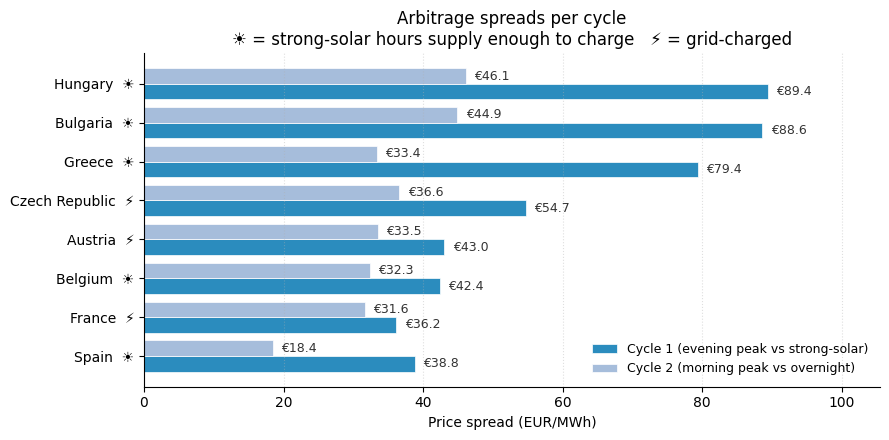

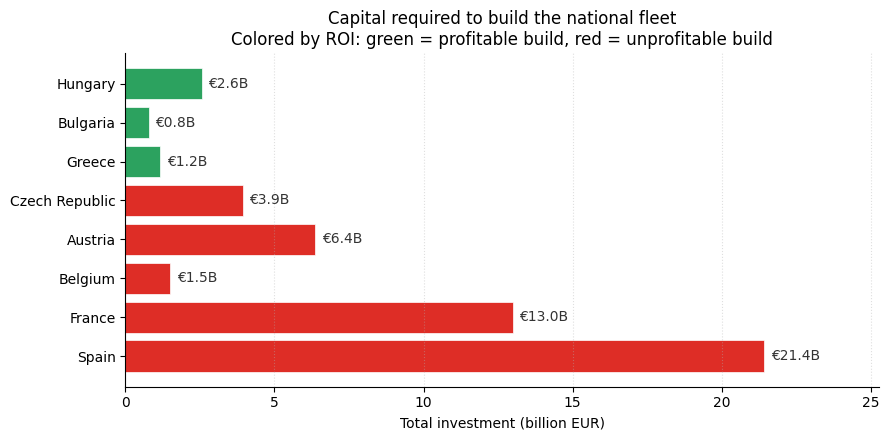

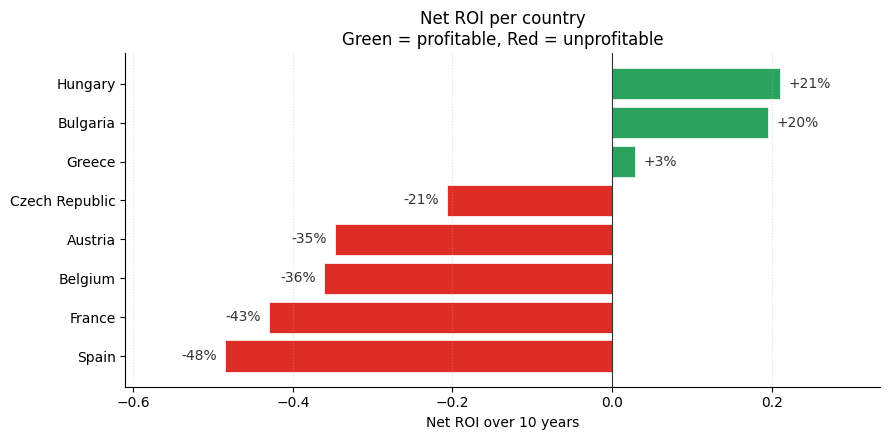

In [ ]:
# Block 6: three charts telling the macro story:
#
# Chart 1 — Cycle 1 vs cycle 2 spreads + solar feasibility (the market structure)
# Chart 2 — Total investment per country (the cost of acting on it)
# Chart 3 — Net ROI per country (the bottom line)

import matplotlib.pyplot as plt
import numpy as np

# Shared data, sorted by Net ROI ascending so the best lands at the bottom of each chart
chart_df = roi_df.sort_values("Net ROI over 10 years (x)", ascending=True).reset_index(drop=True)
countries  = chart_df["Country"].tolist()
roi        = chart_df["Net ROI over 10 years (x)"].values
invest     = chart_df["Total investment (B EUR)"].values
spread1    = chart_df["Cycle 1 spread (EUR/MWh)"].values
spread2    = chart_df["Cycle 2 spread (EUR/MWh)"].values
solar_ok   = chart_df["Solar supply sufficient"].values

y = np.arange(len(countries))


# ──────────────────────────────────────────────────────────────────────────────
# Chart 1 — Arbitrage spreads per cycle, with solar feasibility marker
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_h = 0.4
ax.barh(y - bar_h / 2, spread1, height=bar_h,
        color="#2b8cbe", edgecolor="white", linewidth=0.5, label="Cycle 1 (evening peak vs strong-solar)")
ax.barh(y + bar_h / 2, spread2, height=bar_h,
        color="#a6bddb", edgecolor="white", linewidth=0.5, label="Cycle 2 (morning peak vs overnight)")

# Spread values at bar ends
for i, (s1, s2) in enumerate(zip(spread1, spread2)):
    ax.text(s1 + 1.2, i - bar_h / 2, f"€{s1:.1f}", va="center", ha="left", fontsize=9, color="#333333")
    ax.text(s2 + 1.2, i + bar_h / 2, f"€{s2:.1f}", va="center", ha="left", fontsize=9, color="#333333")

# Solar feasibility marker in the y-tick label
tick_labels = [
    f"{c}  {'☀' if ok else '⚡'}"
    for c, ok in zip(countries, solar_ok)
]
ax.set_yticks(y)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("Price spread (EUR/MWh)")
ax.set_title("Arbitrage spreads per cycle\n☀ = strong-solar hours supply enough to charge   ⚡ = grid-charged")
ax.set_xlim(0, max(spread1.max(), spread2.max()) * 1.18)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Chart 2 — Total investment per country
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
inv_colors = ["#2ca25f" if r >= 0 else "#de2d26" for r in roi]
ax.barh(y, invest, color=inv_colors, edgecolor="white", linewidth=0.5)

for i, v in enumerate(invest):
    ax.text(v + max(invest) * 0.01, i, f"€{v:,.1f}B",
            va="center", ha="left", fontsize=10, color="#333333")

ax.set_yticks(y)
ax.set_yticklabels(countries)
ax.set_xlabel("Total investment (billion EUR)")
ax.set_title("Capital required to build the national fleet\nColored by ROI: green = profitable build, red = unprofitable build")
ax.set_xlim(0, max(invest) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Chart 3 — Net ROI per country
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2ca25f" if r >= 0 else "#de2d26" for r in roi]
ax.barh(y, roi, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="#333333", linewidth=0.8)

xspan = max(roi) - min(roi)
xpad = xspan * 0.015
for i, r in enumerate(roi):
    pct = f"{r*100:+.0f}%"
    if r >= 0:
        ax.text(r + xpad, i, pct, va="center", ha="left", fontsize=10, color="#333333")
    else:
        ax.text(r - xpad, i, pct, va="center", ha="right", fontsize=10, color="#333333")

ax.set_yticks(y)
ax.set_yticklabels(countries)
ax.set_xlabel("Net ROI over 10 years")
ax.set_title("Net ROI per country\nGreen = profitable, Red = unprofitable")
ax.set_xlim(min(roi) - xspan * 0.18, max(roi) + xspan * 0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()